# Mental Rotation 3D Cube Environment Demo

This notebook demonstrates the Mental Rotation 3D Cube environment where you identify matching cube rotations.

In [1]:
import gymnasium as gym
import numpy as np
from IPython.display import display
from PIL import Image

## 1. Create and Inspect Environment (Easy)

In [2]:
env = gym.make("mental_rotation_3d_cube/easy", seed=42)
print(f"Number of segments: {env.unwrapped.num_segments}")
print(f"Action Space: {env.action_space}")
print(f"Available actions: {env.action_space.get_function_names()}")

Number of segments: 4
Action Space: FuncConditional(['rotate', 'stop'])
Available actions: ['rotate', 'stop']


## 2. Reset and View Initial State

Observation shape: (256, 512, 3)
Info: {}


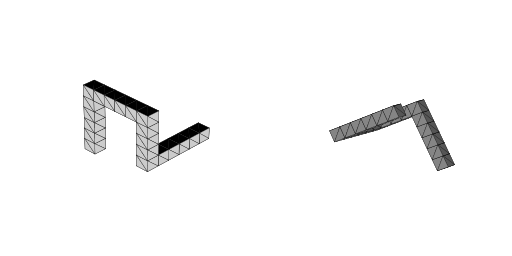


Task: Identify which cube matches the reference after rotation

Task Prompt:
You see two images side-by-side:
- Left: the original 3D object (target orientation)
- Right: the same object under an unknown rotation

Your goal is to rotate the right object back to the original target orientation.

Available actions:
1. 'rotate': Rotate the 3D object by Euler angles. Format: `('rotate', [dyaw, dpitch, droll])` where each of dyaw, dpitch, droll is in degrees between -180 and 180.
2. 'stop': Submit your final rotation. Format: `('stop', 'stop')`

Note: Rotations are applied in the object's local (intrinsic) axes

Success: You succeed if you end up within 10.0 degrees of target orientation.

Please respond with exactly one action and its arguments in the specified format. For example:
- To rotate in yaw: `('rotate', [15.0, 0.0, 0.0])`
- To rotate in roll: `('rotate', [0.0, 0.0, -10.0])`
- To submit: `('stop', 'stop')`


In [3]:
obs, info = env.reset()
print(f"Observation shape: {obs.shape}")
print(f"Info: {info}")

display(Image.fromarray(obs))
print(f"\nTask: Identify which cube matches the reference after rotation")
print(f"\nTask Prompt:\n{env.get_prompt()}")

## 3. Test Manual Actions

In [4]:
# Select a cube (format depends on implementation)
print("Testing manual actions...")
print("Note: Action format depends on environment implementation")

Testing manual actions...
Note: Action format depends on environment implementation


## 4. Test Solver

Initial view:


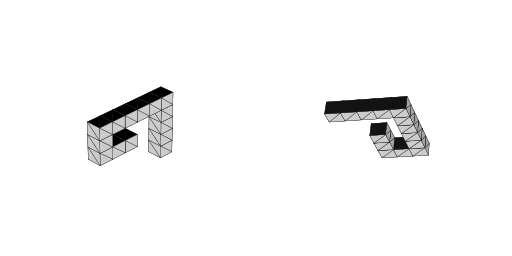


Solver actions: ["('rotate', [-36.0, -27.7, 18.5])", "('rotate', [-36.0, -27.7, 18.5])", "('rotate', [-36.0, -27.7, 18.5])", "('stop', 'stop')"]

Step 1: ('rotate', [-36.0, -27.7, 18.5])


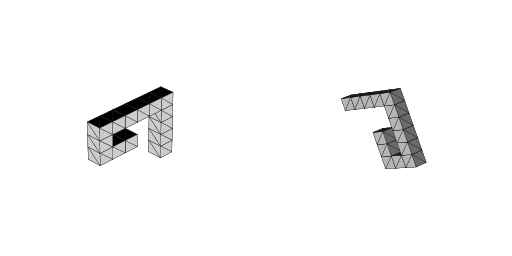


Step 2: ('rotate', [-36.0, -27.7, 18.5])


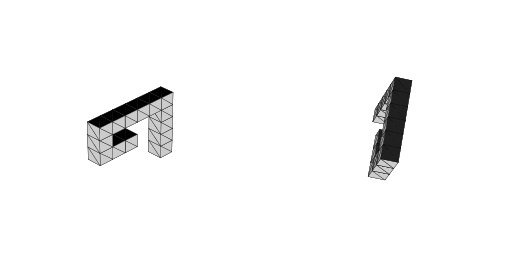


Step 3: ('rotate', [-36.0, -27.7, 18.5])


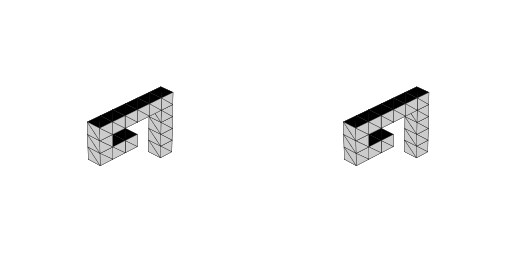


Step 4: ('stop', 'stop')


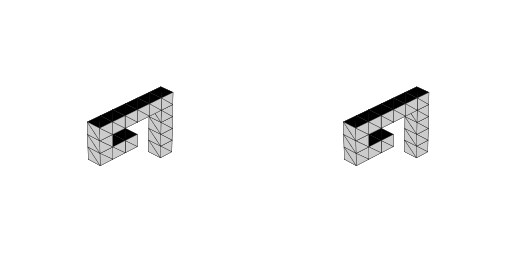


✓ Correct match! Reward: 1.0


In [8]:
env = gym.make("mental_rotation_3d_cube/easy", seed=100)
obs, info = env.reset()
print("Initial view:")
display(Image.fromarray(obs))

# Get solver actions
actions = env.solve(strategy="axis-angle")
print(f"\nSolver actions: {actions}")

# Execute solver actions
for i, action in enumerate(actions):
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"\nStep {i+1}: {action}")
    display(Image.fromarray(obs))
    if terminated:
        print(f"\n✓ Correct match! Reward: {reward}")
        break

env.close()

## 5. Test Hard Difficulty (More Segments)

Hard difficulty - 6 segments (vs easy: 4)


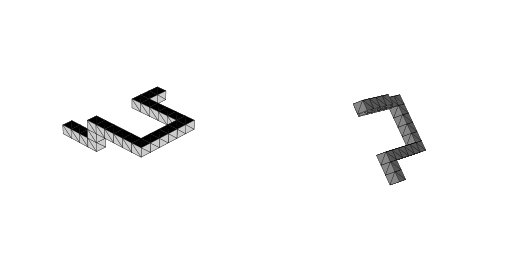


Solution: ["('rotate', [-13.8, 38.8, -31.9])", "('rotate', [-13.8, 38.8, -31.9])", "('rotate', [-13.8, 38.8, -31.9])", "('stop', 'stop')"]
Action: ('rotate', [-13.8, 38.8, -31.9])


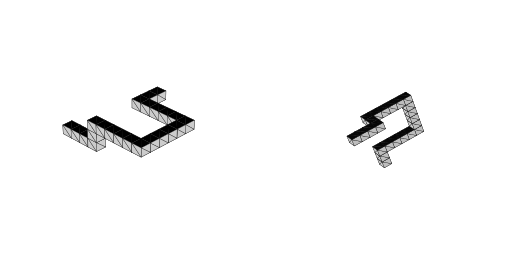

Action: ('rotate', [-13.8, 38.8, -31.9])


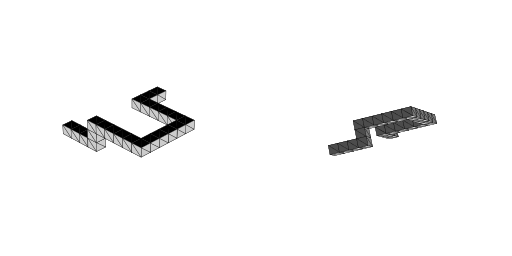

Action: ('rotate', [-13.8, 38.8, -31.9])


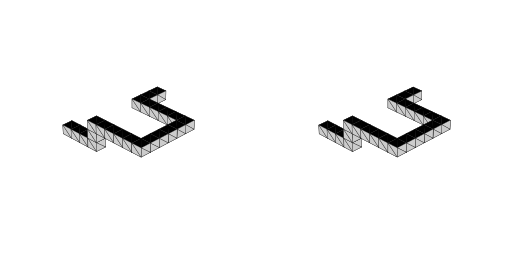

Action: ('stop', 'stop')


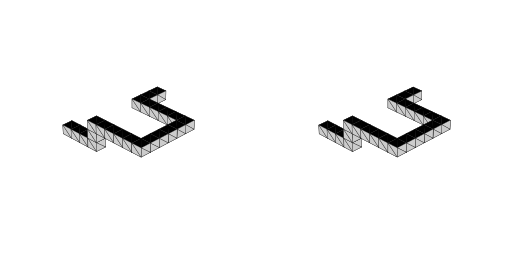

Reward: 1.0


In [9]:
env_hard = gym.make("mental_rotation_3d_cube/hard", seed=42)
obs, info = env_hard.reset()
print(f"Hard difficulty - {env_hard.unwrapped.num_segments} segments (vs easy: 4)")
display(Image.fromarray(obs))

# Get solution
actions = env_hard.solve(strategy="axis-angle")
print(f"\nSolution: {actions}")
for action in actions:
    obs, reward, terminated, truncated, info = env_hard.step(action)
    print(f"Action: {action}")
    display(Image.fromarray(obs))
    if terminated:
        print(f"Reward: {reward}")
        break

env_hard.close()